# 2. EKSTRAKSI KATA KUNCI DENGAN N-GRAM (V2)

**Ekstraksi Kata Kunci dengan N-Gram dan IndoBERT untuk Rekomendasi Wisata Bogor**

---

## Perubahan dari V1:
- Menggunakan `data_preprocessed_ngram.csv` (sudah tanpa stopword)
- Hasil N-gram lebih bermakna karena tidak ada stopword seperti 'yang', 'di', 'dan', dll

In [60]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import matplotlib.pyplot as plt
from IPython.display import display
import pickle
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = './data/'

# Stopwords Indonesia (untuk TF-IDF double protection)
STOPWORDS_ID = {
    'yang', 'di', 'dan', 'dengan', 'ini', 'dari', 'untuk', 'adalah',
    'ke', 'pada', 'ada', 'atau', 'juga', 'bisa', 'dapat', 'akan',
    'tersebut', 'dalam', 'karena', 'oleh', 'secara', 'serta',
    'maupun', 'namun', 'tetapi', 'bahwa', 'saat', 'sangat',
    'lebih', 'sudah', 'telah', 'sedang', 'begitu', 'sehingga',
    'seperti', 'agar', 'jika', 'bila', 'hanya', 'masih', 'lagi',
    'maka', 'yaitu', 'saja', 'itu', 'nya', 'tanpa', 'kalau', 'lain',
    'diri', 'apa', 'siapa', 'mana', 'kapan', 'bagaimana', 'mengapa',
    'sebuah', 'seorang', 'suatu', 'beberapa', 'banyak', 'semua',
    'setiap', 'masing', 'para', 'tiap', 'tak', 'tidak', 'belum',
    'pun', 'pernah', 'selalu', 'terus', 'hingga', 'sampai',
    'antara', 'sebagai', 'tentang', 'terhadap', 'melalui',
    'setelah', 'sebelum', 'kemudian', 'jadi', 'harus', 'perlu',
    'ingin', 'rp', 'article', 'categories', 'tags', 'sumber', 'gambar',
    'merupakan', 'terdapat', 'memiliki', 'berbagai', 'salah', 'satu'
}

print(" Libraries imported!")

 Libraries imported!


In [61]:
# Load preprocessed data (dengan stopword removal)
df = pd.read_csv(f'{DATA_PATH}data_preprocessed_ngram.csv')

# Handle NaN values - replace with empty string
df['deskripsi_ngram'] = df['deskripsi_ngram'].fillna('').astype(str)
df['deskripsi_clean'] = df['deskripsi_clean'].fillna('').astype(str)

info = pd.DataFrame({'Keterangan': ['Total Data', 'Kolom'], 'Nilai': [len(df), str(list(df.columns))]})
print("TABEL: DATA DIMUAT")
display(info)

TABEL: DATA DIMUAT


,Keterangan,Nilai
0,Total Data,296
1,Kolom,"['nama', 'kategori', 'url', 'url_gambar', 'lik..."


## 2.1 Ekstraksi N-gram

In [62]:
def extract_ngrams(text, n):
    """Ekstrak n-gram dari teks (sudah tanpa stopword)"""
    if not isinstance(text, str) or pd.isna(text):
        return []
    text = str(text).strip()
    if not text:
        return []
    words = text.split()
    if len(words) < n:
        return []
    return [' '.join(words[i:i+n]) for i in range(len(words)-n+1)]

def get_top_ngrams(texts, n, top_k=15):
    all_ngrams = []
    for text in texts:
        all_ngrams.extend(extract_ngrams(text, n))
    return Counter(all_ngrams).most_common(top_k)

In [63]:
# Ekstrak global n-grams (menggunakan deskripsi yang sudah tanpa stopword)
texts = df['deskripsi_ngram'].tolist()

top_unigrams = get_top_ngrams(texts, 1, 15)
top_bigrams = get_top_ngrams(texts, 2, 15)
top_trigrams = get_top_ngrams(texts, 3, 15)

# Buat tabel n-grams
ngram_table = pd.DataFrame({
    'Unigram': [f"{w} ({c})" for w, c in top_unigrams],
    'Bigram': [f"{w} ({c})" for w, c in top_bigrams],
    'Trigram': [f"{w} ({c})" for w, c in top_trigrams]
})
ngram_table.index = range(1, len(ngram_table)+1)
ngram_table.index.name = 'Rank'

print("TABEL: TOP 15 N-GRAMS (setelah stopword removal)")
display(ngram_table)

TABEL: TOP 15 N-GRAMS (setelah stopword removal)


,Unigram,Bigram,Trigram
Rank,,,
1,bogor (870),jawa barat (313),bogor jawa barat (291)
2,tempat (561),bogor jawa (291),jawa barat fasilitas (142)
3,air (497),tiket masuk (277),kabupaten bogor jawa (112)
4,wisata (474),kabupaten bogor (253),parkir roda dua (69)
5,lokasi (445),air terjun (236),memakai masker menjaga (65)
6,fasilitas (441),jam operasional (232),masker menjaga jarak (65)
7,curug (426),barat fasilitas (144),tiket masuk tiket (64)
8,jam (397),parkir roda (130),fasilitas fasilitas tersedia (63)
9,alam (365),kolam renang (111),tetap patuhi protokol (63)


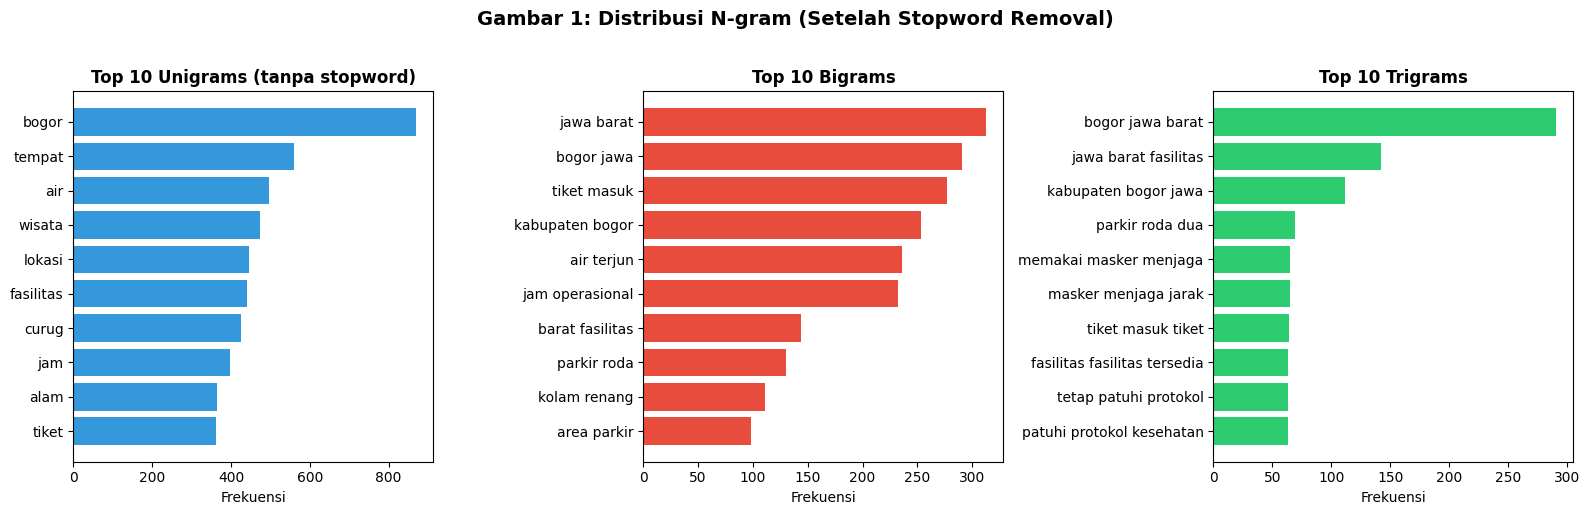

In [64]:
# Visualisasi Top N-grams
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

if top_unigrams:
    words1, counts1 = zip(*top_unigrams[:10])
    axes[0].barh(words1[::-1], counts1[::-1], color='#3498db')
axes[0].set_title('Top 10 Unigrams (tanpa stopword)', fontweight='bold')
axes[0].set_xlabel('Frekuensi')

if top_bigrams:
    words2, counts2 = zip(*top_bigrams[:10])
    axes[1].barh(words2[::-1], counts2[::-1], color='#e74c3c')
axes[1].set_title('Top 10 Bigrams', fontweight='bold')
axes[1].set_xlabel('Frekuensi')

if top_trigrams:
    words3, counts3 = zip(*top_trigrams[:10])
    axes[2].barh(words3[::-1], counts3[::-1], color='#2ecc71')
axes[2].set_title('Top 10 Trigrams', fontweight='bold')
axes[2].set_xlabel('Frekuensi')

plt.suptitle('Gambar 1: Distribusi N-gram (Setelah Stopword Removal)', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_PATH}ngram_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.2 Ekstraksi Kata Kunci per Wisata

In [65]:
def extract_keywords_per_item(text, top_k=5):
    unigrams = extract_ngrams(text, 1)
    bigrams = extract_ngrams(text, 2)
    trigrams = extract_ngrams(text, 3)
    
    top_uni = [w for w, c in Counter(unigrams).most_common(top_k)]
    top_bi = [w for w, c in Counter(bigrams).most_common(top_k)]
    top_tri = [w for w, c in Counter(trigrams).most_common(top_k)]
    
    return {'unigrams': top_uni, 'bigrams': top_bi, 'trigrams': top_tri}

df['keywords'] = df['deskripsi_ngram'].apply(extract_keywords_per_item)
df['unigrams'] = df['keywords'].apply(lambda x: ', '.join(x['unigrams'][:3]) if x['unigrams'] else '')
df['bigrams'] = df['keywords'].apply(lambda x: ', '.join(x['bigrams'][:3]) if x['bigrams'] else '')
df['trigrams'] = df['keywords'].apply(lambda x: ', '.join(x['trigrams'][:2]) if x['trigrams'] else '')

In [66]:
# TABEL: Kata kunci per wisata
keywords_table = df[['nama', 'kategori', 'unigrams', 'bigrams', 'trigrams']].head(10).copy()
keywords_table.columns = ['Nama Wisata', 'Kategori', 'Top Unigrams', 'Top Bigrams', 'Top Trigrams']
keywords_table.index = range(1, len(keywords_table)+1)

print("TABEL: KATA KUNCI N-GRAM PER WISATA (10 Sampel)")
display(keywords_table)

TABEL: KATA KUNCI N-GRAM PER WISATA (10 Sampel)


,Nama Wisata,Kategori,Top Unigrams,Top Bigrams,Top Trigrams
1,Curug Ciampea,Arena,"curug, ciampea, bogor","curug ciampea, ciampea bogor, air terjun","curug ciampea bogor, wisata curug ciampea"
2,Bukit Cirimpak,Arena,"cirimpak, bukit, camping","bukit cirimpak, camping ground, cirimpak camping","bukit cirimpak camping, cirimpak camping ground"
3,Lembah Tepus,Arena,"lembah, tepus, air","lembah tepus, air terjun, sungai air","sungai air terjun, air terjun bertingkat"
4,Sun Water Park Kahuripan,Arena,"kolam, renang, wahana","kolam renang, water park, sun water","sun water park, water park kahuripan"
5,Lembah Pinus Camp & Café,Arena,"blok, pinus, cafe","lembah pinus, pinus camp, camp cafe","lembah pinus camp, pinus camp cafe"
6,Bukit Alas Bandawasa,Arena,"bukit, bogor, gunung","bukit alas, alas bandawasa, kaki gunung","bukit alas bandawasa, kaki gunung salak"
7,Nirwana Golden Park,Arena,"kolam, renang, nirwana","kolam renang, nirwana golden, golden park","nirwana golden park, kolam renang nirwana"
8,Rumah Ibu Waterboom,Arena,"waterboom, bojonggede, dekat","rumah ibu, kecamatan bojonggede, bojonggede ka...","bojonggede kabupaten bogor, rumah ibu waterboom"
9,Gumati Waterpark,Arena,"kolam, pengunjung, bogor","gumati waterpark, membawa makanan, papan seluncur","boleh membawa makanan, membawa makanan minuman"
10,Boash Waterpark,Arena,"kolam, bogor, renang","kolam renang, boash waterpark, waterpark bogor","boash waterpark bogor, bagi orang dewasa"


## 2.3 TF-IDF Vectorization dengan N-gram

In [67]:
# TF-IDF dengan N-gram range (1,3) dan stopword removal
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=5000,
    min_df=1,
    max_df=0.95,
    sublinear_tf=True,
    stop_words=list(STOPWORDS_ID)  # Double protection
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['deskripsi_ngram'])

# Statistik N-gram
vocab = list(tfidf_vectorizer.vocabulary_.keys())
unigram_count = sum(1 for v in vocab if len(v.split()) == 1)
bigram_count = sum(1 for v in vocab if len(v.split()) == 2)
trigram_count = sum(1 for v in vocab if len(v.split()) == 3)

stats = pd.DataFrame({
    'Tipe N-gram': ['Unigram (n=1)', 'Bigram (n=2)', 'Trigram (n=3)', 'Total'],
    'Jumlah': [unigram_count, bigram_count, trigram_count, len(vocab)],
    'Persentase': [f"{unigram_count/len(vocab)*100:.1f}%" if len(vocab) > 0 else '0%', 
                   f"{bigram_count/len(vocab)*100:.1f}%" if len(vocab) > 0 else '0%', 
                   f"{trigram_count/len(vocab)*100:.1f}%" if len(vocab) > 0 else '0%', '100%']
})
print("TABEL: STATISTIK N-GRAM DALAM VOCABULARY TF-IDF")
display(stats)

TABEL: STATISTIK N-GRAM DALAM VOCABULARY TF-IDF


,Tipe N-gram,Jumlah,Persentase
0,Unigram (n=1),2165,43.3%
1,Bigram (n=2),1937,38.7%
2,Trigram (n=3),898,18.0%
3,Total,5000,100%


In [68]:
# TF-IDF Info
tfidf_info = pd.DataFrame({
    'Parameter': ['Matrix Shape', 'Vocabulary Size', 'N-gram Range', 'Max Features', 'Min DF', 'Max DF'],
    'Nilai': [str(tfidf_matrix.shape), len(vocab), '(1, 3)', 5000, 1, 0.95]
})
print("\nTABEL: PARAMETER TF-IDF VECTORIZER")
display(tfidf_info)


TABEL: PARAMETER TF-IDF VECTORIZER


,Parameter,Nilai
0,Matrix Shape,"(296, 5000)"
1,Vocabulary Size,5000
2,N-gram Range,"(1, 3)"
3,Max Features,5000
4,Min DF,1
5,Max DF,0.95


## 2.4 Sampel Matriks TF-IDF

In [69]:
# Ambil feature names (kata/n-gram)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Buat dataframe dari sample TF-IDF (misal 5 dokumen pertama)
sample_indices = range(5)
sample_dense = tfidf_matrix[sample_indices].toarray()
sample_df = pd.DataFrame(sample_dense, columns=feature_names, index=df['nama'].iloc[sample_indices])

# Filter kolom yang nilainya tidak 0 di setidaknya satu dokumen sample
sample_df_filtered = sample_df.loc[:, (sample_df != 0).any(axis=0)]

# Hitung rata-rata TF-IDF untuk setiap fitur di sample ini
mean_tfidf = sample_df_filtered.mean()

# Ambil nama wisata dari sample row untuk filtering (lowercase)
sample_names = [n.lower() for n in df['nama'].iloc[sample_indices]]
tourism_names_global = set(df['nama'].str.lower())

def is_valid_feature(f):
    # 1. Strict Filter: Fitur tidak boleh menjadi substring dari nama wisata sample, dan sebaliknya
    # Ini menghindari 'cirimpak' (ada di 'bukit cirimpak') atau 'curug ciampea bogor' (mengandung 'curug ciampea')
    for name in sample_names:
        if f in name or name in f:
            return False
            
    # 2. Global Filter: Fitur tidak boleh persis sama dengan nama wisata manapun di database
    if f in tourism_names_global:
        return False
        
    return True

# Pisahkan fitur berdasarkan n-gram dan terapkan filter
valid_features = [f for f in mean_tfidf.index if is_valid_feature(f)]

unigrams = [f for f in valid_features if len(f.split()) == 1]
bigrams = [f for f in valid_features if len(f.split()) == 2]
trigrams = [f for f in valid_features if len(f.split()) == 3]

# Ambil top fitur untuk masing-masing kategori (Total 10: 3 Uni, 3 Bi, 4 Tri)
top_unigrams = mean_tfidf[unigrams].sort_values(ascending=False).head(3).index.tolist()
top_bigrams = mean_tfidf[bigrams].sort_values(ascending=False).head(3).index.tolist()
top_trigrams = mean_tfidf[trigrams].sort_values(ascending=False).head(4).index.tolist()

# Gabungkan fitur terpilih
top_features_selected = top_unigrams + top_bigrams + top_trigrams
tfidf_display = sample_df_filtered[top_features_selected]

print("TABEL: SAMPEL MATRIKS TF-IDF (5 Dokumen x 10 Fitur - Strict Name Filtering)")
display(tfidf_display.style.background_gradient(cmap='YlGnBu', axis=None).format("{:.4f}"))

TABEL: SAMPEL MATRIKS TF-IDF (5 Dokumen x 10 Fitur - Strict Name Filtering)


,kolam,camping,wisatawan,air terjun,menuju lokasi,camping ground,pinus camp cafe,telepon kabupaten bogor,harga tiket masuk,air terjun bertingkat
nama,,,,,,,,,,
Curug Ciampea,0.0482,0.0599,0.0378,0.0734,0.0657,0.0271,0.0000,0.0000,0.0285,0.0000
Bukit Cirimpak,0.0000,0.1211,0.0537,0.0000,0.0000,0.1006,0.0000,0.0000,0.0000,0.0000
Lembah Tepus,0.0773,0.0554,0.0613,0.0739,0.0408,0.0286,0.0000,0.0416,0.0000,0.1246
Sun Water Park Kahuripan,0.1184,0.0000,0.0323,0.0000,0.0000,0.0000,0.0000,0.0572,0.0697,0.0000
Lembah Pinus Camp & Café,0.0512,0.0330,0.0701,0.0530,0.0864,0.0357,0.1769,0.0520,0.0374,0.0000


In [70]:
# Simpan hasil
np.save(f'{DATA_PATH}tfidf_matrix.npy', tfidf_matrix.toarray())
with open(f'{DATA_PATH}tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

# Perbaikan: Sertakan 'url', 'url_gambar', 'likes' dalam output agar tersedia untuk rekomendasi
df[['nama', 'kategori', 'url', 'url_gambar', 'likes', 'deskripsi_clean', 'deskripsi_ngram', 'unigrams', 'bigrams', 'trigrams']].to_csv(
    f'{DATA_PATH}data_with_keywords.csv', index=False, encoding='utf-8-sig'
)

files_saved = pd.DataFrame({
    'File': ['tfidf_matrix.npy', 'tfidf_vectorizer.pkl', 'data_with_keywords.csv'],
    'Deskripsi': ['TF-IDF matrix', 'Vectorizer object', 'Data dengan keywords']
})
print("TABEL: FILES SAVED")
display(files_saved)

TABEL: FILES SAVED


,File,Deskripsi
0,tfidf_matrix.npy,TF-IDF matrix
1,tfidf_vectorizer.pkl,Vectorizer object
2,data_with_keywords.csv,Data dengan keywords


In [ ]:
# Summary
summary = pd.DataFrame({
    'Aspek': ['Total Wisata', 'Vocabulary Size', 'TF-IDF Matrix', 'Top Bigram'],
    'Nilai': [len(df), len(vocab), str(tfidf_matrix.shape), 
              f"'{top_bigrams[0][0]}' (freq: {top_bigrams[0][1]})" if top_bigrams else 'N/A']
})
print("\nTABEL: SUMMARY EKSTRAKSI N-GRAM")
display(summary)


TABEL: SUMMARY EKSTRAKSI N-GRAM


,Aspek,Nilai
0,Total Wisata,296
1,Vocabulary Size,5000
2,TF-IDF Matrix,"(296, 5000)"
3,Top Bigram,'a' (freq: i)


: 